# Land-Use Classification of Satellite Images (EuroSAT): MLP vs CNN vs Transfer Learning (ResNet18)

**Deep Learning: Midterm Project**
Author: *Yerlan Utepbergenov, Group BDA-2401*

## Abstract
We study land-use classification of Sentinel-2 satellite images using the EuroSAT RGB dataset (27,000 images, 64×64×3, 10 classes such as Forest, Highway, River and Residential). We compare three models trained on the same fixed 70/15/15 train/validation/test split. The first is a multilayer perceptron (MLP) baseline with two hidden layers. The second is a custom convolutional neural network (CNN) with three convolution–ReLU–max-pooling blocks. The third is an ImageNet-pretrained ResNet18 fine-tuned with a new 10-class output layer.

The MLP reaches only **61.6%** test accuracy despite 6.4M parameters, because flattening the image throws away spatial structure. The CNN reaches **90.3%** with about 3× fewer parameters (2.2M), showing the value of local connectivity and weight sharing. Transfer learning with ResNet18 gives the best result, **97.1%** after only 3 epochs, because its pretrained features (edges, textures, shapes) transfer well to satellite imagery.

An optimizer comparison on the same CNN (5 epochs) shows that adaptive and momentum methods converge much faster than plain SGD (validation accuracy: Adam 85.7%, RMSprop 83.1%, SGD+Momentum 82.0%, SGD 58.9%). A dropout experiment shows that dropout (p = 0.5) cuts the train–validation accuracy gap from 5.1% to 1.9% and lowers validation loss, which means less overfitting. Visualizing the first convolutional layer shows that early layers respond to edges, boundaries and brightness/colour regions.

## 1. Introduction

**Problem.** We classify Sentinel-2 satellite image patches into one of 10 land-use / land-cover classes: AnnualCrop, Forest, HerbaceousVegetation, Highway, Industrial, Pasture, PermanentCrop, Residential, River, SeaLake.
- **Input:** an RGB satellite image of size 64×64×3.
- **Output:** one of 10 land-use class labels.
- **Objective:** get the highest possible test accuracy, and understand *why* some models work better than others.

**Motivation.** Automatic land-use mapping is useful for agriculture monitoring, urban planning and environmental protection. Labelling satellite images by hand is slow. The task is a good fit for deep learning because classes differ in **texture and spatial patterns** (field stripes, street grids, river shapes, water colour). These patterns are hard to describe with hand-made rules but CNNs can learn them from data.

**Approach.**
1. **MLP baseline**: a fully connected network on flattened pixels.
2. **Custom CNN**: convolution + pooling layers that use the spatial structure of images.
3. **Optimizer comparison**: SGD, SGD+Momentum, RMSprop and Adam on the same CNN.
4. **Regularization experiment**: CNN with and without Dropout.
5. **Transfer learning**: ResNet18 pretrained on ImageNet, fine-tuned on EuroSAT.
6. **Evaluation**: accuracy, loss curves, confusion matrices, parameter counts, training time, and filter/activation visualization.

## 0. Setup (imports, seed, device)

In [1]:
import time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Reproducibility: fix every random seed
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
set_seed()

# Use GPU (CUDA or Apple MPS) if available, otherwise CPU
device = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device, "| PyTorch:", torch.__version__)

Device: mps | PyTorch: 2.14.1


## 2. Data and Preprocessing

**Dataset:** EuroSAT RGB (Helber et al., 2019). It contains Sentinel-2 satellite images of Europe. It is downloaded automatically with `torchvision.datasets.EuroSAT` (hosted on Hugging Face).
- 27,000 labelled images, 10 classes.
- 64×64 pixels, 3 channels (RGB).
- EuroSAT has no official split, so we make one.

**Split (fixed seed; the same split is used for every model):**
- Train: 70% (18,900 images)
- Validation: 15% (4,050 images), used to monitor training and compare settings
- Test: 15% (4,050 images), used only for the final comparison

**Preprocessing:**
- `ToTensor()` scales pixels to [0, 1].
- `Normalize(mean, std)` uses per-channel mean/std **computed on the training set only** (no information leak from val/test). Each channel then has about zero mean and unit variance, which makes optimization easier.
- **Augmentation (train only):** `RandomHorizontalFlip()` and `RandomVerticalFlip()`. A satellite image has no "up" direction, so a flipped field is still the same class. This gives the model more varied data and reduces overfitting.

In [2]:
root = "./data"
full_raw = torchvision.datasets.EuroSAT(root, download=True)   # PIL images, used for stats & plots
classes = full_raw.classes
targets = np.array(full_raw.targets)
N = len(full_raw)

# Fixed 70 / 15 / 15 split (same indices for every experiment)
perm = torch.randperm(N, generator=torch.Generator().manual_seed(SEED)).tolist()
n_train, n_val = int(0.70 * N), int(0.15 * N)
train_idx = perm[:n_train]
val_idx   = perm[n_train:n_train + n_val]
test_idx  = perm[n_train + n_val:]

# Per-channel mean / std computed on the TRAINING images only
pixels = torch.stack([T.functional.to_tensor(full_raw[i][0]) for i in train_idx])  # (n, 3, 64, 64)
MEAN = pixels.mean(dim=(0, 2, 3)).tolist()
STD  = pixels.std(dim=(0, 2, 3)).tolist()
del pixels
print("mean:", np.round(MEAN, 3), "std:", np.round(STD, 3))

train_tf = T.Compose([T.RandomHorizontalFlip(), T.RandomVerticalFlip(),
                      T.ToTensor(), T.Normalize(MEAN, STD)])
plain_tf = T.Compose([T.ToTensor(), T.Normalize(MEAN, STD)])   # val / test (no augmentation)

full_aug   = torchvision.datasets.EuroSAT(root, transform=train_tf)
full_plain = torchvision.datasets.EuroSAT(root, transform=plain_tf)
train_set       = Subset(full_aug,   train_idx)   # with augmentation
train_set_plain = Subset(full_plain, train_idx)   # without augmentation (dropout experiment)
val_set         = Subset(full_plain, val_idx)
test_set        = Subset(full_plain, test_idx)

BATCH = 128
train_loader       = DataLoader(train_set,       batch_size=BATCH, shuffle=True,
                                generator=torch.Generator().manual_seed(SEED))
train_loader_plain = DataLoader(train_set_plain, batch_size=BATCH, shuffle=True,
                                generator=torch.Generator().manual_seed(SEED))
val_loader  = DataLoader(val_set,  batch_size=256)
test_loader = DataLoader(test_set, batch_size=256)

print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")
print("Image shape (C, H, W):", tuple(train_set[0][0].shape), "| Classes:", len(classes))

mean: [0.344 0.38  0.408] std: [0.203 0.137 0.116]
Train: 18900 | Val: 4050 | Test: 4050
Image shape (C, H, W): (3, 64, 64) | Classes: 10


### Class distribution

,train,val,test,total
AnnualCrop,2062,466,472,3000
Forest,2127,431,442,3000
HerbaceousVegetation,2097,445,458,3000
Highway,1728,381,391,2500
Industrial,1770,352,378,2500
Pasture,1392,309,299,2000
PermanentCrop,1733,388,379,2500
Residential,2096,454,450,3000
River,1743,382,375,2500
SeaLake,2152,442,406,3000


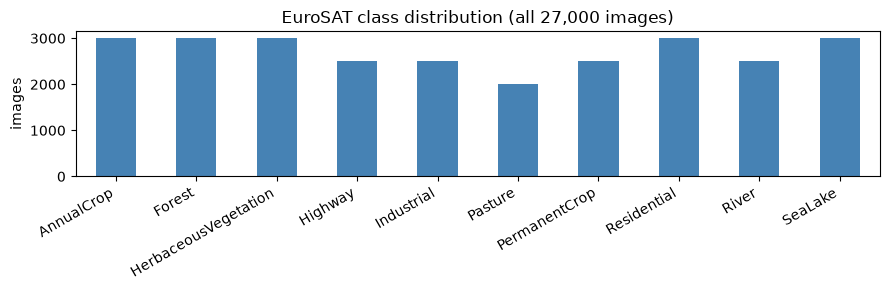

In [3]:
counts = pd.DataFrame({
    "train": np.bincount(targets[train_idx], minlength=10),
    "val":   np.bincount(targets[val_idx],   minlength=10),
    "test":  np.bincount(targets[test_idx],  minlength=10)}, index=classes)
counts["total"] = counts.sum(axis=1)
display(counts)

counts["total"].plot.bar(figsize=(9, 3), title="EuroSAT class distribution (all 27,000 images)", color="steelblue")
plt.ylabel("images"); plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

The dataset is **mildly imbalanced**: most classes have 3,000 images, while Pasture has 2,000 and Highway, Industrial, PermanentCrop and River have 2,500. The imbalance is small, so plain accuracy is still a reasonable metric. The random split keeps roughly the same proportions in train, val and test. The confusion matrix also shows per-class errors.

### Sample images

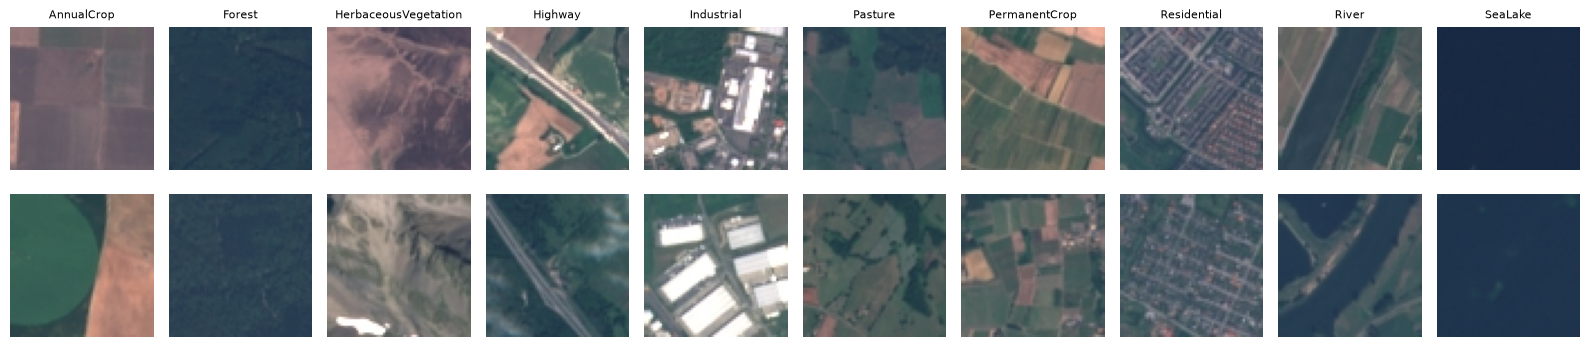

In [4]:
fig, axes = plt.subplots(2, 10, figsize=(16, 3.8))
for c in range(10):                                  # two examples of every class
    idx = np.where(targets == c)[0][:2]
    for row in range(2):
        axes[row, c].imshow(full_raw[idx[row]][0]); axes[row, c].axis("off")
    axes[0, c].set_title(classes[c], fontsize=8)
plt.tight_layout(); plt.show()

## 3. Methods

### 3.1 Shared training setup
- **Loss function:** Cross-Entropy, the standard loss for multi-class classification. It combines softmax with negative log-likelihood.
- **Metric:** accuracy.
- The helper functions below train any model and record train/val loss and accuracy for every epoch, plus the training time.

In [5]:
def count_params(model):
    # Number of trainable parameters
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

@torch.no_grad()
def evaluate(model, loader, criterion=nn.CrossEntropyLoss()):
    # Returns (average loss, accuracy) on a data loader
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        total_loss += criterion(out, y).item() * len(y)
        correct += (out.argmax(1) == y).sum().item()
        n += len(y)
    return total_loss / n, correct / n

def train_model(model, optimizer, epochs, loader=None, name=""):
    # Standard training loop. Returns a history dict.
    loader = loader or train_loader
    criterion = nn.CrossEntropyLoss()
    hist = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    start = time.time()
    for ep in range(1, epochs + 1):
        model.train()
        tot, correct, n = 0.0, 0, 0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()          # backpropagation
            optimizer.step()         # weight update
            tot += loss.item() * len(y)
            correct += (out.argmax(1) == y).sum().item()
            n += len(y)
        vl, va = evaluate(model, val_loader)
        hist["train_loss"].append(tot / n); hist["train_acc"].append(correct / n)
        hist["val_loss"].append(vl);        hist["val_acc"].append(va)
        print(f"[{name}] epoch {ep:2d}/{epochs} | train loss {tot/n:.3f} acc {correct/n:.3f} "
              f"| val loss {vl:.3f} acc {va:.3f}")
    hist["time"] = time.time() - start
    print(f"[{name}] training time: {hist['time']:.1f}s")
    return hist

def plot_history(hists, title=""):
    # Plot loss and accuracy curves for one or more runs
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    for name, h in hists.items():
        ep = range(1, len(h["train_loss"]) + 1)
        ax[0].plot(ep, h["train_loss"], "-o", ms=3, label=f"{name} train")
        ax[0].plot(ep, h["val_loss"], "--", label=f"{name} val")
        ax[1].plot(ep, h["train_acc"], "-o", ms=3, label=f"{name} train")
        ax[1].plot(ep, h["val_acc"], "--", label=f"{name} val")
    ax[0].set(title=f"{title}: loss", xlabel="epoch", ylabel="loss")
    ax[1].set(title=f"{title}: accuracy", xlabel="epoch", ylabel="accuracy")
    for a in ax: a.legend(fontsize=8); a.grid(alpha=.3)
    plt.tight_layout(); plt.show()

### 3.2 Baseline: Multilayer Perceptron (MLP)

| Layer | Details |
|---|---|
| Input | Flatten 3×64×64 → 12,288 |
| Hidden 1 | Linear 12,288 → 512, **ReLU**, Dropout 0.2 |
| Hidden 2 | Linear 512 → 256, **ReLU**, Dropout 0.2 |
| Output | Linear 256 → 10 (logits, softmax is inside the loss) |

- **Loss:** Cross-Entropy. **Optimizer:** Adam. **Learning rate:** 0.001. **Epochs:** 10. **Batch size:** 128.
- **Weakness:** an MLP treats every pixel independently. It ignores which pixels are neighbours and has no translation invariance, so we expect it to perform poorly on images.

MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=12288, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=256, out_features=10, bias=True)
  )
)
Trainable parameters: 6,425,866


[MLP] epoch  1/10 | train loss 1.869 acc 0.371 | val loss 1.363 acc 0.488


[MLP] epoch  2/10 | train loss 1.354 acc 0.504 | val loss 1.229 acc 0.536


[MLP] epoch  3/10 | train loss 1.272 acc 0.533 | val loss 1.225 acc 0.563


[MLP] epoch  4/10 | train loss 1.246 acc 0.547 | val loss 1.192 acc 0.569


...

[MLP] epoch  6/10 | train loss 1.190 acc 0.571 | val loss 1.107 acc 0.602


[MLP] epoch  7/10 | train loss 1.154 acc 0.579 | val loss 1.117 acc 0.599


[MLP] epoch  8/10 | train loss 1.144 acc 0.588 | val loss 1.096 acc 0.614


[MLP] epoch  9/10 | train loss 1.129 acc 0.590 | val loss 1.071 acc 0.621


[MLP] epoch 10/10 | train loss 1.112 acc 0.596 | val loss 1.066 acc 0.624
[MLP] training time: 76.6s


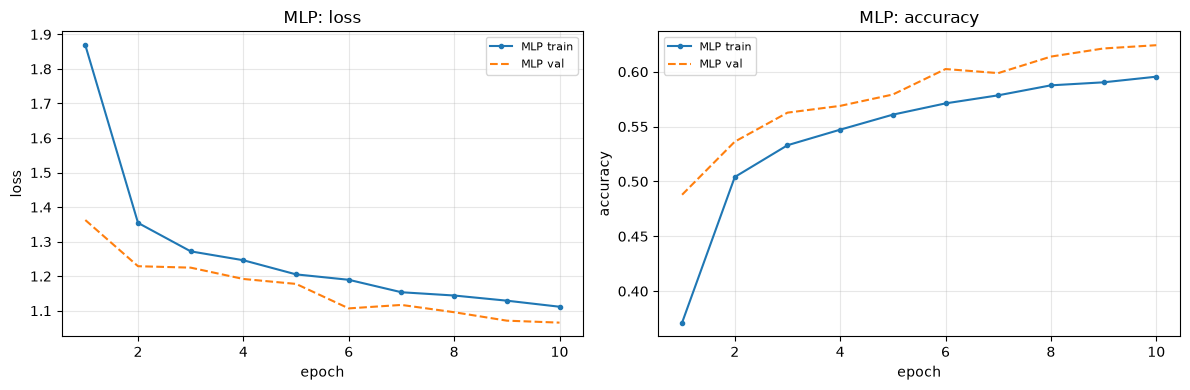

In [6]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * 64 * 64, 512), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(512, 256),         nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(256, 10))
    def forward(self, x):
        return self.net(x)

set_seed()
mlp = MLP().to(device)
print(mlp)
print("Trainable parameters:", f"{count_params(mlp):,}")

EPOCHS = 10
hist_mlp = train_model(mlp, torch.optim.Adam(mlp.parameters(), lr=1e-3), EPOCHS, name="MLP")
plot_history({"MLP": hist_mlp}, "MLP")

### 3.3 Custom CNN

| Block | Layers | Output shape |
|---|---|---|
| Input | n/a | 3 × 64 × 64 |
| Conv block 1 | Conv2d(3→32, k=3, s=1, p=1) → ReLU → MaxPool(2) | 32 × 32 × 32 |
| Conv block 2 | Conv2d(32→64, k=3, s=1, p=1) → ReLU → MaxPool(2) | 64 × 16 × 16 |
| Conv block 3 | Conv2d(64→128, k=3, s=1, p=1) → ReLU → MaxPool(2) | 128 × 8 × 8 |
| Classifier | Flatten (8192) → Linear 8192→256 → ReLU → Dropout(p) → Linear 256→10 | 10 |

**Why these settings?**
- **Kernel size 3×3:** small and cheap. Stacking 3×3 kernels grows the receptive field (the VGG idea) with few parameters.
- **Number of filters 32 → 64 → 128:** the image gets smaller after each pooling, so we add more channels to keep enough capacity for more abstract features.
- **Stride 1:** the convolution looks at every position. Downsampling is done by pooling instead.
- **Padding 1:** with k=3 and p=1 the spatial size stays the same ("same" padding), so border information is not lost.
- **MaxPool 2×2:** halves height and width. This reduces computation and gives a little translation invariance.

**Output-size calculation.** Formula: $O = \left\lfloor \frac{W - K + 2P}{S} \right\rfloor + 1$

- Conv1: W=64, K=3, P=1, S=1 → (64 − 3 + 2)/1 + 1 = **64** → output 32×64×64
- MaxPool(2, stride 2): (64 − 2)/2 + 1 = **32** → 32×32×32
- Conv2: (32 − 3 + 2)/1 + 1 = 32 → pool → **64×16×16**
- Conv3: (16 − 3 + 2)/1 + 1 = 16 → pool → **128×8×8** → flatten = 8192

**Parameters of Conv1:** (3·3·3 + 1)·32 = 896. The code below checks the shapes and parameter counts.

**Training:** Cross-Entropy, Adam (lr = 0.001), 10 epochs, batch 128, Dropout p = 0.5.

In [7]:
class CNN(nn.Module):
    def __init__(self, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),   nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1), nn.ReLU(), nn.MaxPool2d(2))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 10))
    def forward(self, x):
        return self.classifier(self.features(x))

# Check feature-map sizes layer by layer with a dummy image
x = torch.zeros(1, 3, 64, 64)
for layer in CNN().features:
    x = layer(x)
    print(f"{layer.__class__.__name__:10s} -> {tuple(x.shape[1:])}")

# Parameters per layer
rows = [(n, p.numel()) for n, p in CNN().named_parameters()]
display(pd.DataFrame(rows, columns=["parameter", "count"]))
print("Total trainable parameters:", f"{count_params(CNN()):,}")

Conv2d     -> (32, 64, 64)
ReLU       -> (32, 64, 64)
MaxPool2d  -> (32, 32, 32)
Conv2d     -> (64, 32, 32)
ReLU       -> (64, 32, 32)
MaxPool2d  -> (64, 16, 16)
Conv2d     -> (128, 16, 16)
ReLU       -> (128, 16, 16)
MaxPool2d  -> (128, 8, 8)


,parameter,count
0,features.0.weight,864
1,features.0.bias,32
2,features.3.weight,18432
3,features.3.bias,64
4,features.6.weight,73728
5,features.6.bias,128
6,classifier.1.weight,2097152
7,classifier.1.bias,256
8,classifier.4.weight,2560
9,classifier.4.bias,10


Total trainable parameters: 2,193,226


[CNN] epoch  1/10 | train loss 1.104 acc 0.602 | val loss 0.725 acc 0.736


[CNN] epoch  2/10 | train loss 0.706 acc 0.750 | val loss 0.650 acc 0.775


[CNN] epoch  3/10 | train loss 0.607 acc 0.785 | val loss 0.537 acc 0.804


[CNN] epoch  4/10 | train loss 0.522 acc 0.818 | val loss 0.590 acc 0.787


[CNN] epoch  5/10 | train loss 0.474 acc 0.838 | val loss 0.414 acc 0.851


[CNN] epoch  6/10 | train loss 0.422 acc 0.859 | val loss 0.339 acc 0.885


[CNN] epoch  7/10 | train loss 0.361 acc 0.876 | val loss 0.388 acc 0.873


[CNN] epoch  8/10 | train loss 0.346 acc 0.885 | val loss 0.295 acc 0.898


[CNN] epoch  9/10 | train loss 0.297 acc 0.899 | val loss 0.330 acc 0.885


[CNN] epoch 10/10 | train loss 0.286 acc 0.904 | val loss 0.276 acc 0.900
[CNN] training time: 143.3s


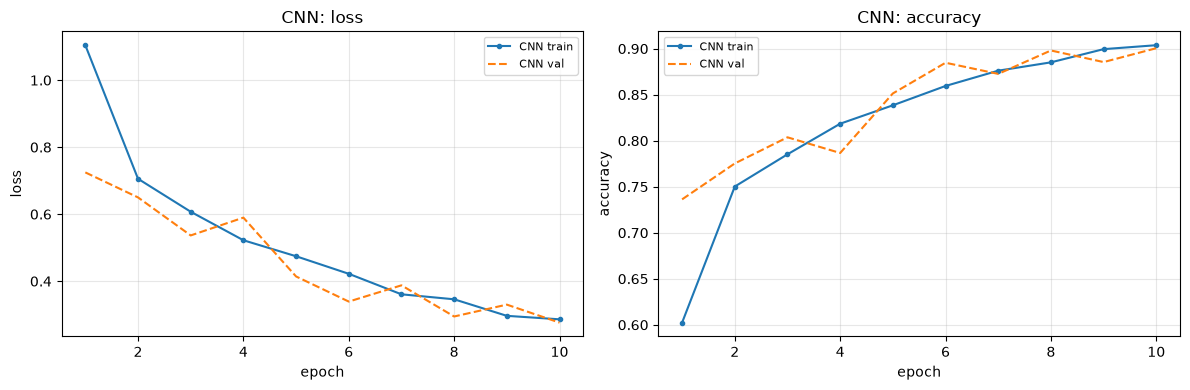

In [8]:
set_seed()
cnn = CNN().to(device)
hist_cnn = train_model(cnn, torch.optim.Adam(cnn.parameters(), lr=1e-3), EPOCHS, name="CNN")
plot_history({"CNN": hist_cnn}, "CNN")

### 3.4 Transfer learning: ResNet18 pretrained on ImageNet

**Idea.** A network trained on ImageNet (1.2M images, 1000 classes) has already learned general visual features: edges, colours, textures and object parts. We reuse these weights as the starting point and **fine-tune** them on our data. This usually gives higher accuracy with less training, because the model does not have to learn the low-level features from scratch.

**Steps:**
1. Load `resnet18` with `IMAGENET1K_V1` weights. ResNet uses *residual (skip) connections*, `y = F(x) + x`, which help gradients flow through deep networks.
2. Replace the final layer `fc: 512 → 1000` with `fc: 512 → 10` for our 10 classes.
3. Feed our 64×64 images directly. ResNet ends with global average pooling, so it accepts any input size; 64×64 gives a 2×2 map before pooling.
4. Fine-tune **all** layers with Adam using a small learning rate (1e-4), so the pretrained features are not destroyed. We train for 3 epochs because the model converges fast.

Final layer: Linear(in_features=512, out_features=10, bias=True)
Trainable parameters: 11,181,642


[ResNet18] epoch  1/3 | train loss 0.359 acc 0.886 | val loss 0.129 acc 0.956


[ResNet18] epoch  2/3 | train loss 0.112 acc 0.963 | val loss 0.098 acc 0.968


[ResNet18] epoch  3/3 | train loss 0.077 acc 0.975 | val loss 0.082 acc 0.975
[ResNet18] training time: 73.9s


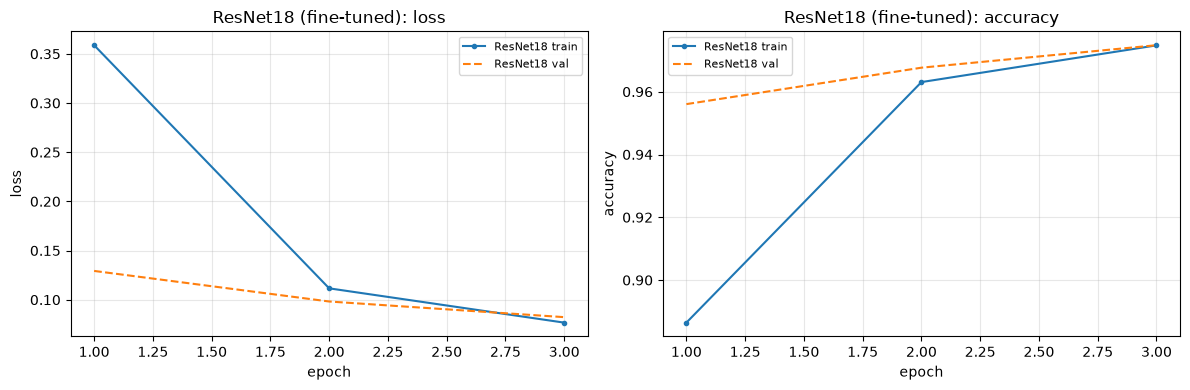

In [9]:
from torchvision.models import resnet18, ResNet18_Weights

def make_resnet():
    m = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)  # pretrained ImageNet weights
    m.fc = nn.Linear(m.fc.in_features, 10)                # new head: 512 -> 10 classes
    return m

set_seed()
resnet = make_resnet().to(device)
print("Final layer:", resnet.fc)
print("Trainable parameters:", f"{count_params(resnet):,}")

hist_resnet = train_model(resnet, torch.optim.Adam(resnet.parameters(), lr=1e-4), 3, name="ResNet18")
plot_history({"ResNet18": hist_resnet}, "ResNet18 (fine-tuned)")

## 4. Optimization and Training Analysis

### 4.1 Optimizer comparison
We train the **same CNN architecture** on the **same data split**, from the **same initial weights** (same seed), for 5 epochs with four optimizers:

| Optimizer | Learning rate | Idea |
|---|---|---|
| SGD | 0.01 | plain gradient step: w ← w − η∇L |
| SGD + Momentum | 0.01, momentum 0.9 | adds a "velocity" that smooths updates and speeds up movement in consistent directions |
| RMSprop | 0.001 | divides by a running average of squared gradients, so each parameter gets its own adaptive step |
| Adam | 0.001 | momentum + RMSprop-style adaptive steps, with bias correction |

In [10]:
OPT_EPOCHS = 5
optimizers = {
    "SGD":          lambda p: torch.optim.SGD(p, lr=0.01),
    "SGD+Momentum": lambda p: torch.optim.SGD(p, lr=0.01, momentum=0.9),
    "RMSprop":      lambda p: torch.optim.RMSprop(p, lr=0.001),
    "Adam":         lambda p: torch.optim.Adam(p, lr=0.001),
}
opt_hists = {}
for name, make_opt in optimizers.items():
    set_seed()                       # identical initial weights for a fair comparison
    model = CNN().to(device)
    opt_hists[name] = train_model(model, make_opt(model.parameters()), OPT_EPOCHS, name=name)

[SGD] epoch  1/5 | train loss 2.107 acc 0.220 | val loss 1.857 acc 0.289


[SGD] epoch  2/5 | train loss 1.727 acc 0.342 | val loss 1.570 acc 0.383


[SGD] epoch  3/5 | train loss 1.495 acc 0.417 | val loss 1.358 acc 0.482


[SGD] epoch  4/5 | train loss 1.343 acc 0.501 | val loss 1.353 acc 0.517


[SGD] epoch  5/5 | train loss 1.249 acc 0.547 | val loss 1.197 acc 0.589
[SGD] training time: 70.4s


...

[Adam] epoch  1/5 | train loss 1.142 acc 0.581 | val loss 0.844 acc 0.691


[Adam] epoch  2/5 | train loss 0.721 acc 0.743 | val loss 0.632 acc 0.777


[Adam] epoch  3/5 | train loss 0.625 acc 0.782 | val loss 0.521 acc 0.814


[Adam] epoch  4/5 | train loss 0.545 acc 0.808 | val loss 0.451 acc 0.837


[Adam] epoch  5/5 | train loss 0.489 acc 0.835 | val loss 0.411 acc 0.857
[Adam] training time: 71.3s


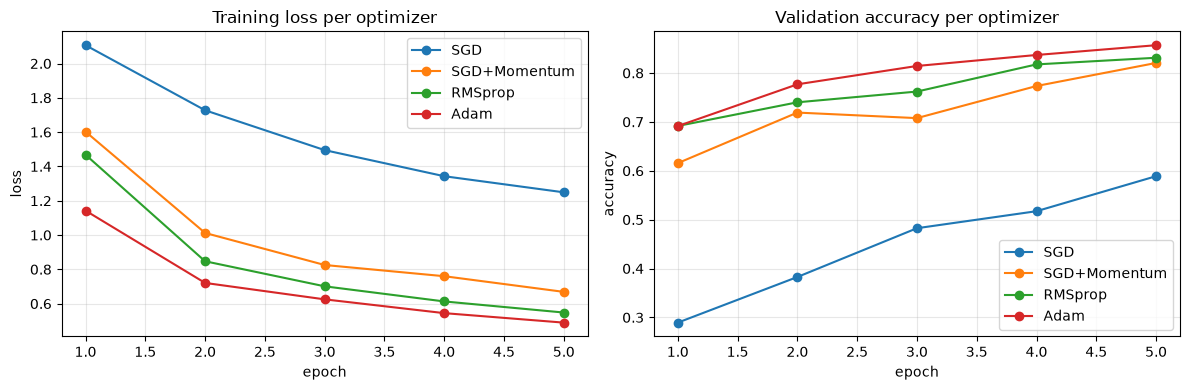

,final train loss,final val acc,best val acc,time (s)
SGD,1.249,0.589,0.589,70.408
SGD+Momentum,0.669,0.820,0.820,71.310
RMSprop,0.548,0.831,0.831,70.482
Adam,0.489,0.857,0.857,71.311


In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for name, h in opt_hists.items():
    ep = range(1, OPT_EPOCHS + 1)
    ax[0].plot(ep, h["train_loss"], "-o", label=name)
    ax[1].plot(ep, h["val_acc"], "-o", label=name)
ax[0].set(title="Training loss per optimizer", xlabel="epoch", ylabel="loss")
ax[1].set(title="Validation accuracy per optimizer", xlabel="epoch", ylabel="accuracy")
for a in ax: a.legend(); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

opt_table = pd.DataFrame({
    "final train loss": [h["train_loss"][-1] for h in opt_hists.values()],
    "final val acc":    [h["val_acc"][-1]    for h in opt_hists.values()],
    "best val acc":     [max(h["val_acc"])   for h in opt_hists.values()],
    "time (s)":         [h["time"]           for h in opt_hists.values()],
}, index=opt_hists.keys()).round(3)
opt_table

**Discussion.**
- **Training loss and accuracy:** Adam is best (val acc 85.7%, train loss 0.489), then RMSprop (83.1%), then SGD+Momentum (82.0%). Plain SGD is far behind (58.9%, loss 1.249).
- **Convergence:** Adam reaches 69% val accuracy after the *first* epoch. Plain SGD needs all 5 epochs to reach 59%. With a single fixed small step, SGD moves slowly through flat regions of the loss. **Momentum** builds up velocity in consistent directions, which roughly gives the 82% vs 59% difference here. **RMSprop/Adam** scale each parameter's step by its recent gradient size, so parameters with small gradients still learn quickly. Adam combines both ideas, which is why it is the fastest.
- **Stability:** SGD+Momentum and RMSprop curves are a bit noisier (e.g. a dip at epoch 3 for momentum). Adam improves steadily.
- **Training time:** all four take about the same time (≈70 s for 5 epochs). The cost per step is almost identical, because the forward and backward passes dominate. So the choice of optimizer affects **how many epochs** you need, not the time per epoch.
- **Conclusion:** we use **Adam (lr = 0.001)** for the main CNN. Plain SGD would need many more epochs, or a larger learning rate and a schedule, to catch up.

### 4.2 Regularization experiment: Dropout

**Dropout** randomly sets a fraction *p* of neurons to zero during training. The network cannot rely on any single neuron, so it learns more robust and redundant features. At test time all neurons are used (PyTorch rescales automatically). Dropout acts like averaging many smaller networks, which reduces **overfitting**.

**Setup:** the same CNN with `dropout=0.0` vs `dropout=0.5`, Adam lr=0.001, 10 epochs. We train **without data augmentation** here so that overfitting is easy to see. We compare the **gap between training and validation** performance.

[dropout=0.0] epoch  1/10 | train loss 0.990 acc 0.641 | val loss 0.699 acc 0.751


[dropout=0.0] epoch  2/10 | train loss 0.596 acc 0.787 | val loss 0.584 acc 0.790


[dropout=0.0] epoch  3/10 | train loss 0.482 acc 0.827 | val loss 0.444 acc 0.843


[dropout=0.0] epoch  4/10 | train loss 0.392 acc 0.861 | val loss 0.514 acc 0.826


[dropout=0.0] epoch  5/10 | train loss 0.325 acc 0.884 | val loss 0.398 acc 0.853


...

[dropout=0.5] epoch  6/10 | train loss 0.343 acc 0.882 | val loss 0.388 acc 0.865


[dropout=0.5] epoch  7/10 | train loss 0.315 acc 0.890 | val loss 0.346 acc 0.874


[dropout=0.5] epoch  8/10 | train loss 0.254 acc 0.913 | val loss 0.270 acc 0.909


[dropout=0.5] epoch  9/10 | train loss 0.214 acc 0.927 | val loss 0.275 acc 0.906


[dropout=0.5] epoch 10/10 | train loss 0.196 acc 0.933 | val loss 0.268 acc 0.914
[dropout=0.5] training time: 141.3s


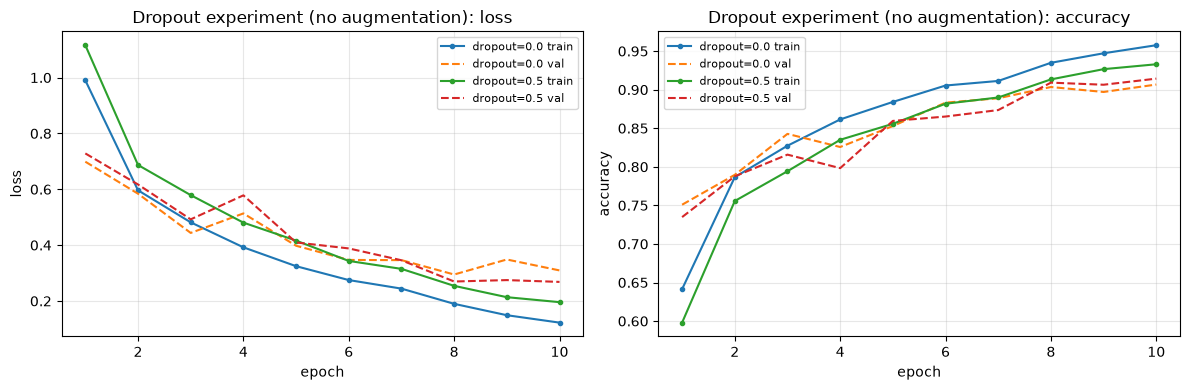

,final train acc,final val acc,train-val gap,min val loss,final val loss
dropout=0.0,0.958,0.907,0.051,0.295,0.309
dropout=0.5,0.933,0.914,0.019,0.268,0.268


In [12]:
reg_hists = {}
for p in [0.0, 0.5]:
    set_seed()
    model = CNN(dropout=p).to(device)
    reg_hists[f"dropout={p}"] = train_model(model, torch.optim.Adam(model.parameters(), lr=1e-3),
                                            EPOCHS, loader=train_loader_plain, name=f"dropout={p}")
plot_history(reg_hists, "Dropout experiment (no augmentation)")

pd.DataFrame({
    "final train acc": [h["train_acc"][-1] for h in reg_hists.values()],
    "final val acc":   [h["val_acc"][-1]   for h in reg_hists.values()],
    "train-val gap":   [h["train_acc"][-1] - h["val_acc"][-1] for h in reg_hists.values()],
    "min val loss":    [min(h["val_loss"]) for h in reg_hists.values()],
    "final val loss":  [h["val_loss"][-1]  for h in reg_hists.values()],
}, index=reg_hists.keys()).round(3)

**Discussion.**
- **Without dropout** the model fits the training data more and more closely: train accuracy 95.8% vs val 90.7%, a **gap of 5.1%**. Validation loss stops improving after epoch 8 (0.295) and rises again (0.309 at the end) while training loss keeps falling (0.122). This is the classic sign of **overfitting**: the network starts to memorise training images.
- **With dropout p = 0.5** the training accuracy is lower (93.3%) because training is harder: half the neurons in the dense layer are randomly switched off. But validation accuracy is **higher (91.4%)**, the **gap shrinks to 1.9%**, and the final validation loss is lower (0.268).
- **Effect on training:** dropout makes training loss decrease more slowly and noisily. **Effect on generalization:** better. Neurons cannot co-adapt, so the network learns more robust features, similar to averaging many thinned networks.
- In the main models we also use data augmentation (flips), which reduces overfitting even further.

## 5. Experiments and Results

### 5.1 Quantitative comparison (test set)

In [13]:
models = {"MLP": (mlp, hist_mlp), "CNN": (cnn, hist_cnn), "ResNet18 (TL)": (resnet, hist_resnet)}
results = []
for name, (m, h) in models.items():
    _, test_acc = evaluate(m, test_loader)
    results.append({"model": name, "test accuracy": round(test_acc, 4),
                    "trainable params": f"{count_params(m):,}",
                    "epochs": len(h["train_loss"]),
                    "training time (s)": round(h["time"], 1),
                    "time / epoch (s)": round(h["time"] / len(h["train_loss"]), 1)})
results = pd.DataFrame(results).set_index("model")
results

,test accuracy,trainable params,epochs,training time (s),time / epoch (s)
model,,,,,
MLP,0.6156,"6,425,866",10,76.6,7.7
CNN,0.9030,"2,193,226",10,143.3,14.3
ResNet18 (TL),0.9711,"11,181,642",3,73.9,24.6


### 5.2 Training and validation loss curves (all models)

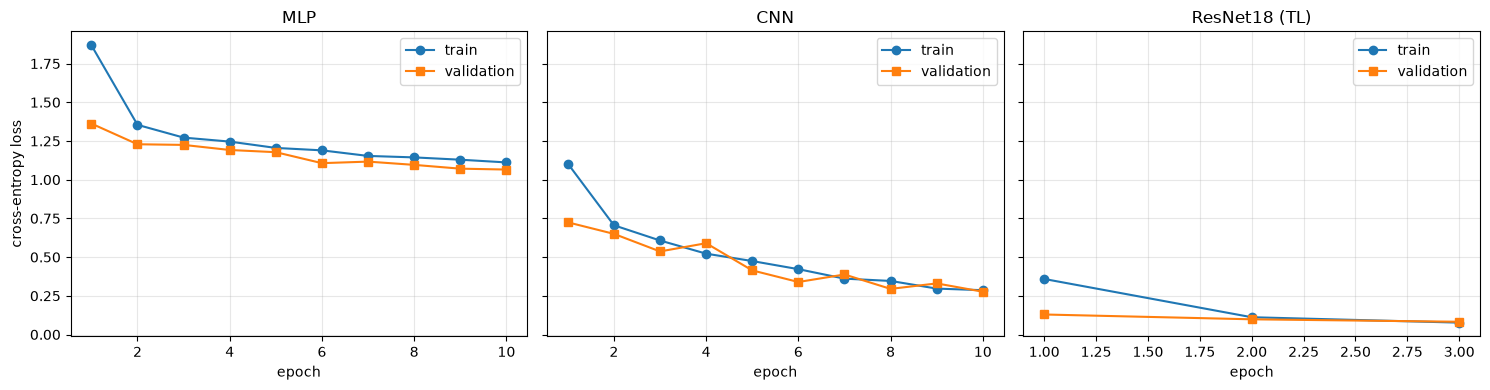

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (name, (_, h)) in zip(axes, models.items()):
    ep = range(1, len(h["train_loss"]) + 1)
    ax.plot(ep, h["train_loss"], "-o", label="train")
    ax.plot(ep, h["val_loss"], "-s", label="validation")
    ax.set(title=name, xlabel="epoch"); ax.legend(); ax.grid(alpha=.3)
axes[0].set_ylabel("cross-entropy loss")
plt.tight_layout(); plt.show()

### 5.3 Confusion matrices (test set)

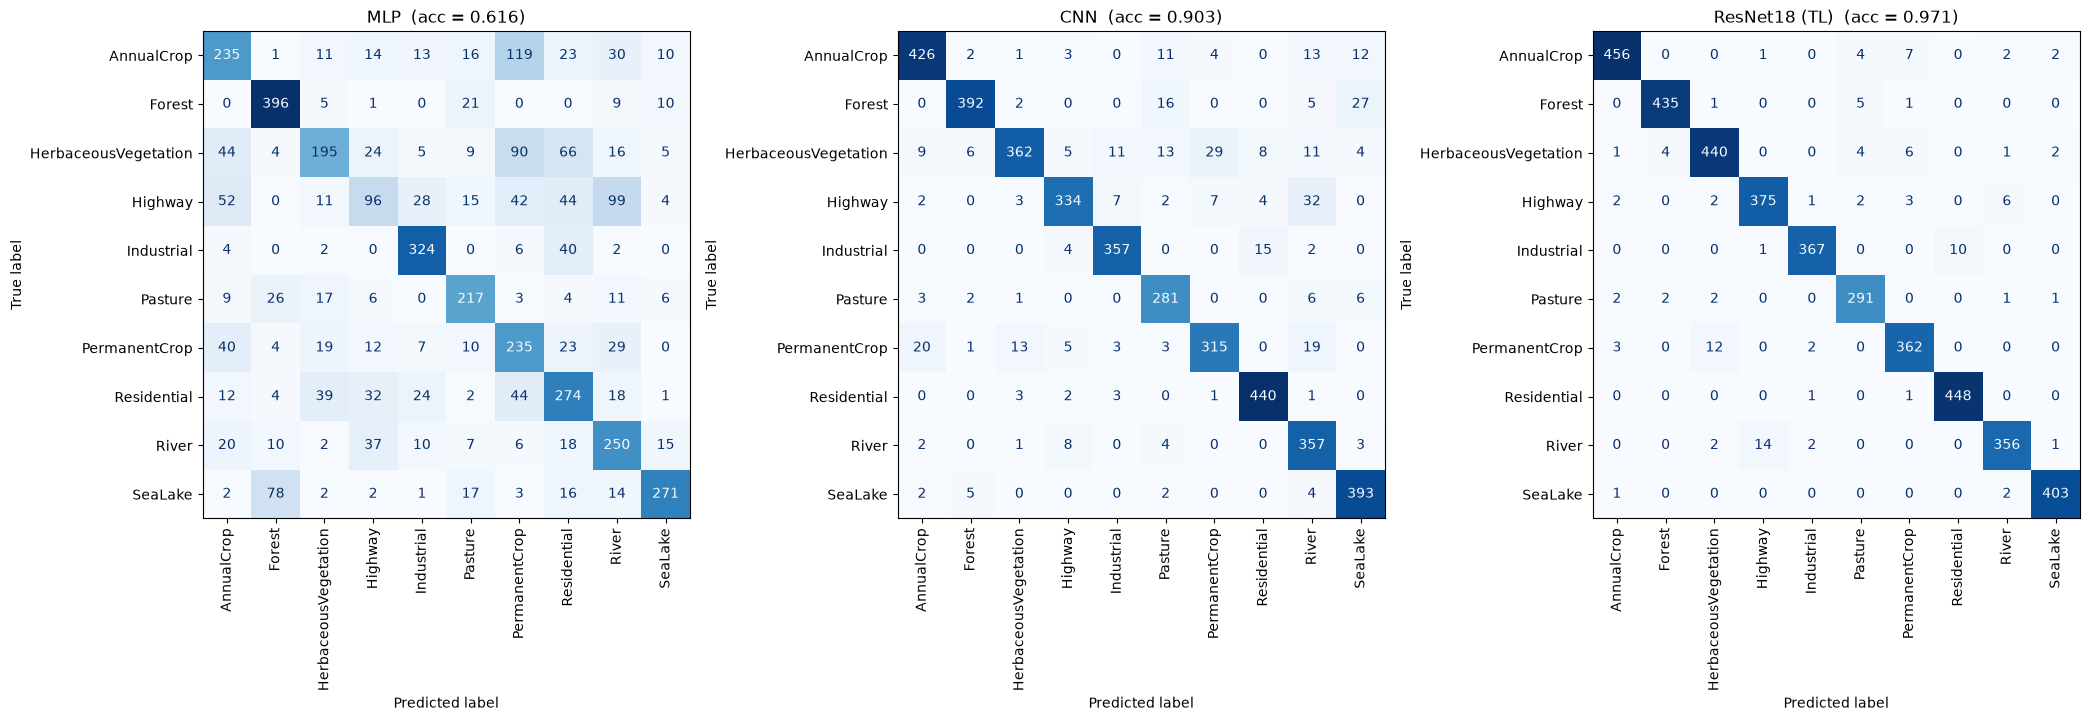

In [15]:
@torch.no_grad()
def predict(model, loader):
    model.eval()
    preds, labels = [], []
    for x, y in loader:
        preds.append(model(x.to(device)).argmax(1).cpu()); labels.append(y)
    return torch.cat(labels).numpy(), torch.cat(preds).numpy()

fig, axes = plt.subplots(1, 3, figsize=(21, 7.5))
for ax, (name, (m, _)) in zip(axes, models.items()):
    y_true, y_pred = predict(m, test_loader)
    ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred), display_labels=classes).plot(
        ax=ax, cmap="Blues", colorbar=False, xticks_rotation="vertical")
    ax.set_title(f"{name}  (acc = {(y_true == y_pred).mean():.3f})")
plt.tight_layout(); plt.show()

**What the confusion matrices show:**
- **MLP:** errors everywhere. Big confusions are AnnualCrop → PermanentCrop (119), Highway → River (99), HerbaceousVegetation → PermanentCrop (90) and SeaLake → Forest (78). Without spatial features the MLP mostly uses colour: dark-green forest and dark water look alike, and so do different kinds of farmland.
- **CNN:** most errors are gone. The remaining ones are between visually similar classes: Highway ↔ River (both are long thin lines crossing the image), HerbaceousVegetation ↔ PermanentCrop, and Forest → SeaLake (both dark, uniform textures).
- **ResNet18:** almost perfectly diagonal. The few errors left make sense: River → Highway (14), PermanentCrop → HerbaceousVegetation (12), Industrial → Residential (10). Even a human would find some of these patches ambiguous.

### 5.4 Feature visualization

**(a) Filters of the first convolutional layer.** Conv1 has 32 filters of size 3×3×3. We show them as tiny RGB images.

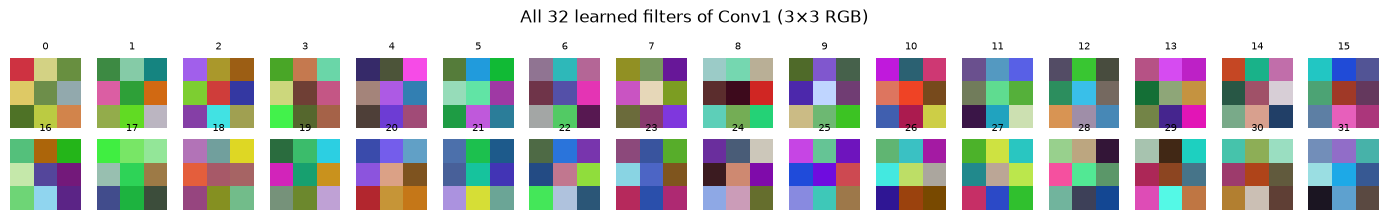

In [16]:
w = cnn.features[0].weight.detach().cpu()          # shape (32, 3, 3, 3)
w = (w - w.min()) / (w.max() - w.min())             # scale to [0, 1] for display
fig, axes = plt.subplots(2, 16, figsize=(14, 2.2))
for i, ax in enumerate(axes.flat):
    ax.imshow(w[i].permute(1, 2, 0)); ax.axis("off"); ax.set_title(str(i), fontsize=7)
plt.suptitle("All 32 learned filters of Conv1 (3×3 RGB)"); plt.tight_layout(); plt.show()

**(b) Activation maps of Conv1 for two test images** (first 8 channels after ReLU).

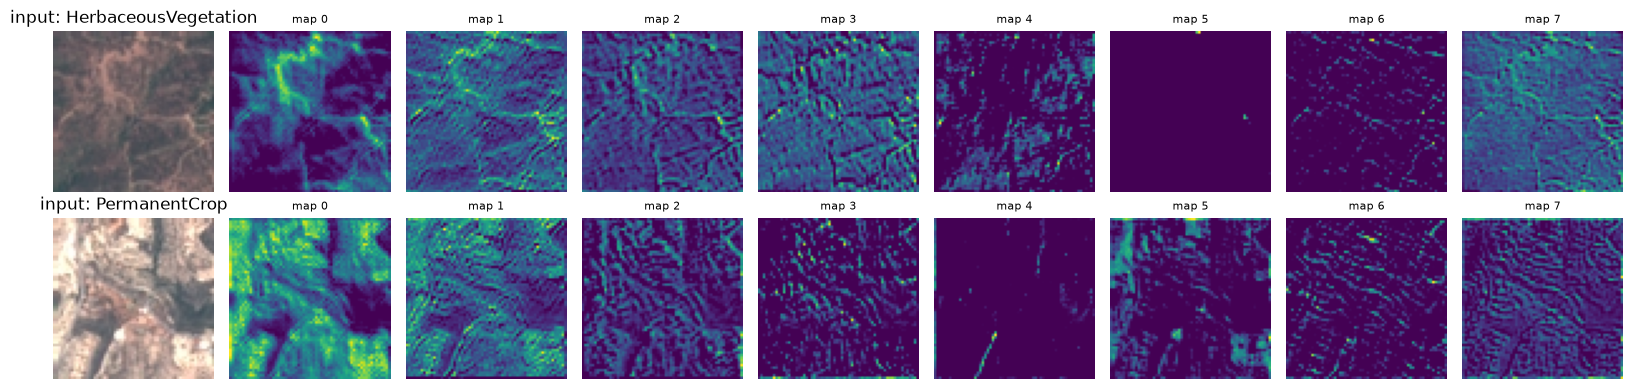

In [17]:
cnn.eval()
fig, axes = plt.subplots(2, 9, figsize=(16, 4))
for row, idx in enumerate([3, 7]):                  # two sample test images
    img, y = test_set[idx]
    with torch.no_grad():
        act = cnn.features[1](cnn.features[0](img.unsqueeze(0).to(device)))[0].cpu()  # Conv1 + ReLU
    show = (img * torch.tensor(STD).view(3, 1, 1) + torch.tensor(MEAN).view(3, 1, 1)).clamp(0, 1)
    axes[row, 0].imshow(show.permute(1, 2, 0)); axes[row, 0].set_title(f"input: {classes[y]}")
    for c in range(8):
        axes[row, c + 1].imshow(act[c], cmap="viridis"); axes[row, c + 1].set_title(f"map {c}", fontsize=8)
for ax in axes.flat: ax.axis("off")
plt.tight_layout(); plt.show()

**Interpretation.**
- The **3×3 filters** are tiny, so they are hard to read by eye. Each one is a small pattern of colour weights. Some compare neighbouring pixels (light vs dark → **edge detectors**), and others respond to particular **colours**, such as green vegetation or brownish soil.
- The **activation maps** make this clearer. Some channels (e.g. map 1, map 7) light up along **edges and boundaries**: field borders, paths, ridges. Others (map 0) respond to **bright or uniformly coloured regions**. A few produce fine **texture** responses (map 3, map 6). Map 5 is almost empty for the first image, so that filter looks for a pattern that is rare in this image.
- So **early CNN layers capture low-level information: edges, colour and simple texture.** They do not yet "know" the class. Deeper layers combine these simple responses into larger patterns (field stripes, street grids, river shapes) that identify the land-use class.

### 5.5 Discussion: complexity vs training cost vs performance

| Model | Test acc. | Trainable params | Epochs | Train time | Time/epoch |
|---|---|---|---|---|---|
| MLP | 61.6% | 6.43 M | 10 | ≈77 s | ≈8 s |
| CNN (ours) | 90.3% | 2.19 M | 10 | ≈143 s | ≈14 s |
| ResNet18 (transfer) | **97.1%** | 11.18 M | 3 | ≈74 s | ≈25 s |

- **More parameters ≠ better.** The MLP has 3× more parameters than the CNN but is 29 points worse. Most of its parameters sit in the first layer (12,288 × 512 ≈ 6.3M). The CNN shares the same small 3×3 filters across the whole image (**weight sharing**), so it needs fewer parameters and has a built-in bias for local patterns.
- **Compute is not the same as parameter count.** The CNN has fewer parameters than the MLP but is slower per epoch, because each filter slides over every pixel position, which means many more multiply–add operations.
- **ResNet18** is the largest and slowest per epoch (≈1.7× the CNN). But it starts from pretrained features, so it needs only 3 epochs and its **total** training time is the lowest of the three, with the best accuracy (+6.8 points over our CNN). The price is model size (11M parameters, ≈45 MB) and slower inference. This could matter on small devices.
- **Practical choice:** if accuracy matters most → ResNet18 transfer learning. If a small, fast model is needed → our CNN is a good compromise at 90%. The MLP is not suitable for images.

## 6. Conclusion
**Summary of findings**
1. Spatial structure matters. The CNN (90.3%) beats the MLP (61.6%) with 3× fewer parameters, thanks to local receptive fields, weight sharing and pooling.
2. Transfer learning works best. An ImageNet-pretrained ResNet18 reaches **97.1%** in only 3 epochs, even though ImageNet contains everyday photos and not satellite images. Low- and mid-level features such as edges and textures are general.
3. The optimizer has a big effect on convergence speed. Adam > RMSprop ≈ SGD+Momentum >> plain SGD after 5 epochs, at the same cost per epoch.
4. Dropout reduces overfitting. It cuts the train–val gap from 5.1% to 1.9% and slightly improves validation accuracy.
5. Early conv layers act as edge, boundary and colour detectors.

**Limitations**
- Short training (10 epochs for MLP/CNN, 3 for ResNet18) and no hyperparameter search, so all models could improve.
- One random split and one seed, with no error bars across multiple runs.
- Only the RGB bands are used. EuroSAT also has 13 multispectral bands (e.g. near-infrared), which are very informative for vegetation.
- Images come only from Europe, so performance may drop on other regions.

**Possible improvements**
- Train longer with a learning-rate schedule (e.g. cosine) and early stopping on validation loss.
- Add Batch Normalization to the CNN, and use stronger augmentation (90° rotations, colour jitter).
- Fine-tune with larger inputs (e.g. 224×224, the size ResNet was trained on) or try other architectures (ResNet50, EfficientNet).
- Use all 13 spectral bands. Report mean ± std over several seeds.